![](images/AlexNet_arch.jpg)

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# ImageNet dataset (smaller dataset)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2593s 15us/step


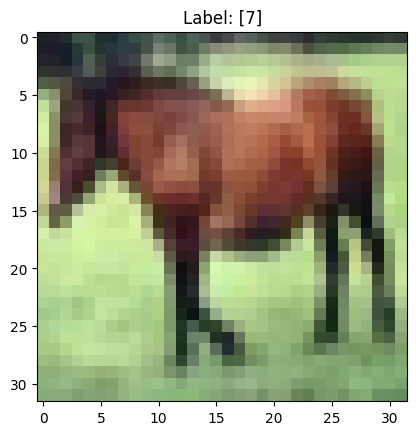

Image Shape: (32, 32, 3)


In [3]:
# See the pictures
sample_index = 7

pic = x_train[sample_index]
plt.imshow(pic)
plt.title(f"Label: {y_train[sample_index]}")
plt.show()
print(f"Image Shape: {x_train[sample_index].shape}")

In [4]:
inputs = layers.Input(shape=(32, 32, 3))

# Preprocessing
re_size = layers.Resizing(224, 224)(inputs)
re_scale = layers.Rescaling(1.0 / 255)(re_size)

# --------------------------------------------------------------------------------------------------
# Layer 1
Conv_1 = layers.Conv2D(filters=96, kernel_size=(11, 11), strides=4, use_bias=False)(re_scale)
Batch_norm1 = layers.BatchNormalization()(Conv_1)
Act_1 = layers.Activation("relu")(Batch_norm1)
Pool_1 = layers.MaxPooling2D(pool_size=3, strides=2)(Act_1)

# Layer 2
Conv_2 = layers.Conv2D(filters=256, kernel_size=(5, 5), padding="same", use_bias=False)(Pool_1)
Batch_norm2 = layers.BatchNormalization()(Conv_2)
Act_2 = layers.Activation("relu")(Batch_norm2)
Pool_2 = layers.MaxPooling2D(pool_size=3, strides=2)(Act_2)

# Layer 3
Conv_3 = layers.Conv2D(filters=384, kernel_size=(3, 3), padding="same", use_bias=False)(Pool_2)
Batch_norm3 = layers.BatchNormalization()(Conv_3)
Act_3 = layers.Activation("relu")(Batch_norm3)

# Layer 4
Conv_4 = layers.Conv2D(filters=384, kernel_size=(3, 3), padding="same", use_bias=False)(Act_3)
Batch_norm4 = layers.BatchNormalization()(Conv_4)
Act_4 = layers.Activation("relu")(Batch_norm4)

# Layer 5
Conv_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), padding="same", use_bias=False)(Act_4)
Batch_norm5 = layers.BatchNormalization()(Conv_5)
Act_5 = layers.Activation("relu")(Batch_norm5)
Pool_5 = layers.MaxPooling2D(pool_size=3, strides=2)(Act_5)

# --------------------------------------------------------------------------------------------------
# Fully Connected Layers
flat = layers.Flatten()(Pool_5)
FC_6 = layers.Dense(units=4096, activation="relu")(flat)
Drop_1 = layers.Dropout(0.5)(FC_6)

FC_7 = layers.Dense(units=4096, activation="relu")(Drop_1)
Drop_2 = layers.Dropout(0.5)(FC_7)

FC_8 = layers.Dense(units=10, activation="softmax")(Drop_2)

In [5]:
Alexnet_model = models.Model(inputs=inputs, outputs=FC_8, name="AlexNet")

In [6]:
Alexnet_model.summary()

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       884,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 46,792,106 (178.50 MB)

 Trainable params: 46,789,354 (178.49 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [7]:
Alexnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = Alexnet_model.fit(
                  x=x_train,
                  y=y_train,
                  batch_size=64,
                  epochs=10,
                  validation_data=(x_test, y_test),
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 78ms/step - accuracy: 0.4396 - loss: 1.5871 - val_accuracy: 0.4949 - val_loss: 1.4218
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.6240 - loss: 1.0595 - val_accuracy: 0.6542 - val_loss: 0.9797
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.7115 - loss: 0.8263 - val_accuracy: 0.5159 - val_loss: 1.4225
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7622 - loss: 0.6834 - val_accuracy: 0.5976 - val_loss: 1.2794
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7983 - loss: 0.5800 - val_accuracy: 0.7064 - val_loss: 0.8278
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8291 - loss: 0.4934 - val_accuracy: 0.7602 - val_loss: 0.7004
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8550 - loss: 0.4185 - val_accuracy: 0.6801 - val_loss: 1.0323
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.8778 - loss: 0.3518 - 

In [10]:
# evaluate
test_loss, test_acc = Alexnet_model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100}")

Test Accuracy: 81.54000043869019


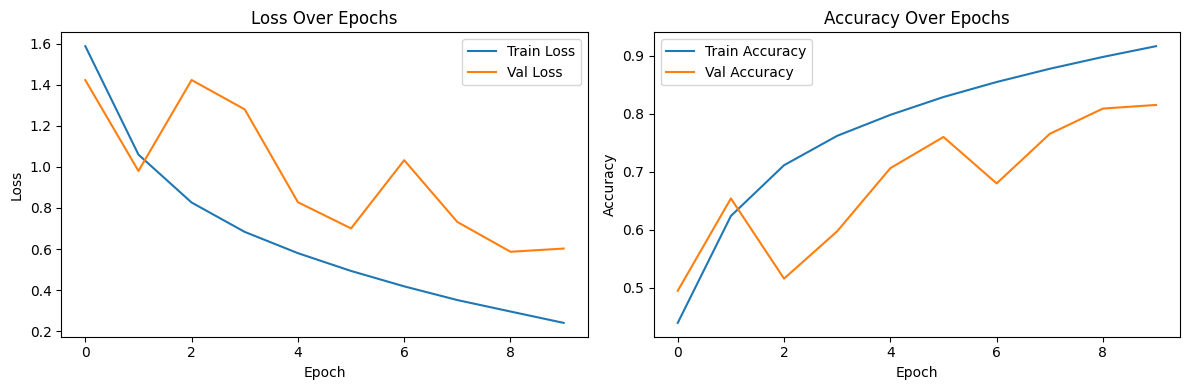

In [11]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()